In [ ]:
import pandas as pd

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, f1_score

df = pd.read_csv("/content/student_data.csv")

In [ ]:
print(df.head())
print(df.info())
print(df.isnull().sum())

   Student_Id  Age  Gender  StudyHour  Attendance  Marks Result
0           1   18  female        2.5        75.0     55   fail
1           2   19    male        4.0        85.0     69   pass
2           3   18  female        3.5        89.0     75   pass
3           4   20    male        5.0        79.0     89   pass
4           5   18  female        2.5        75.0     55   fail
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Student_Id  13 non-null     int64  
 1   Age         13 non-null     int64  
 2   Gender      13 non-null     object 
 3   StudyHour   13 non-null     float64
 4   Attendance  11 non-null     float64
 5   Marks       13 non-null     int64  
 6   Result      13 non-null     object 
dtypes: float64(2), int64(3), object(2)
memory usage: 860.0+ bytes
None
Student_Id    0
Age           0
Gender        0
StudyHour     0
Attendanc

In [ ]:
print(df.isnull().sum())

Student_Id    0
Age           0
Gender        0
StudyHour     0
Attendance    2
Marks         0
Result        0
dtype: int64


In [ ]:
x = df[["Age", "StudyHour", "Attendance", "Marks"]]
y = df["Result"]
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Training sample:")

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Actual:", y_test)
print("Predicted:", y_pred)




Training sample:
Actual: [1 1 0]
Predicted: [1 1 0]


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

recall_val = recall_score(y_test, y_pred)
print("Recall:", recall_val)

f1_val = f1_score(y_test, y_pred)
print("F1 Score:", f1_val)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
[[1 0]
 [0 2]]


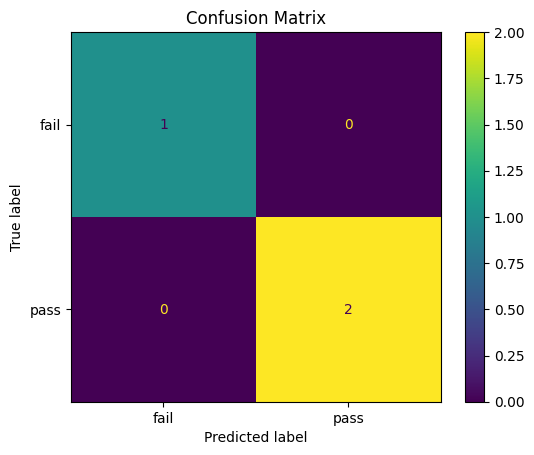

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

2.1

In [ ]:
import pandas as pd

df = pd.read_csv('/content/student_dataset_500.csv')
df.head()

,Student_ID,Name,Age,Gender,Department,Attendance_Percentage,Math_Score,Science_Score,English_Score,Assignment_Score,Study_Hours_Per_Week,Final_Grade
0,1,Student_001,24,Male,Computer Science,70.11,90,64,50,66,9.1,B
1,2,Student_002,21,Male,Computer Science,92.13,62,73,74,61,14.6,F
2,3,Student_003,22,Male,Computer Science,71.34,40,59,36,76,28.8,A
3,4,Student_004,24,Female,Electronics,56.54,95,42,75,66,13.2,C
4,5,Student_005,20,Male,Civil,92.38,54,92,46,96,25.5,C


In [ ]:
X = df[['Age', 'Attendance_Percentage',
        'Math_Score', 'Science_Score',
        'English_Score', 'Assignment_Score',
        'Study_Hours_Per_Week']]

y = df['Final_Grade']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

print(le.classes_)

['A' 'B' 'C' 'D' 'F']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (400, 7)
Testing data: (100, 7)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(X_test)

print(y_pred)

[0 1 4 2 0 2 1 0 1 0 3 1 3 1 0 2 1 1 3 1 2 1 1 0 1 0 1 0 3 2 2 2 0 0 0 1 1
 2 2 1 0 2 3 1 2 0 0 0 0 0 2 0 2 1 2 2 2 1 0 1 2 1 2 1 2 0 3 0 1 1 1 0 1 1
 0 2 2 1 1 2 1 2 1 1 0 1 1 2 2 1 2 1 1 0 0 2 2 1 1 1]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.25

Classification Report:
              precision    recall  f1-score   support

           A       0.15      0.22      0.18        18
           B       0.31      0.35      0.33        34
           C       0.25      0.26      0.25        27
           D       0.33      0.12      0.18        16
           F       0.00      0.00      0.00         5

    accuracy                           0.25       100
   macro avg       0.21      0.19      0.19       100
weighted avg       0.25      0.25      0.24       100



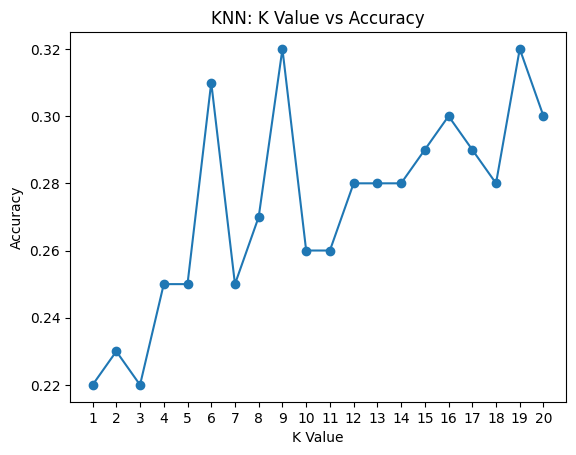

In [ ]:
import matplotlib.pyplot as plt

k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, pred))

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN: K Value vs Accuracy")
plt.xticks(k_values)
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv('/content/student_dataset_500.csv')

# Features
X = df[['Age', 'Attendance_Percentage',
        'Math_Score', 'Science_Score',
        'English_Score', 'Assignment_Score',
        'Study_Hours_Per_Week']]

# Target
y = df['Final_Grade']

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

Accuracy: 0.25

Classification Report:
              precision    recall  f1-score   support

           A       0.15      0.22      0.18        18
           B       0.31      0.35      0.33        34
           C       0.25      0.26      0.25        27
           D       0.33      0.12      0.18        16
           F       0.00      0.00      0.00         5

    accuracy                           0.25       100
   macro avg       0.21      0.19      0.19       100
weighted avg       0.25      0.25      0.24       100



In [ ]:
1,18,female,2.5,75,55,fail
2,19,male,4,85,69,pass
3,18,female,3.5,89,75,pass
4,20,male,5,79,89,pass
5,18,female,2.5,75,55,fail
6,19,male,4,85,69,pass
7,18,female,3.5,89,75,pass
8,20,male,5,null,89,pass
9,18,female,2.5,75,55,fail
10,19,male,4,85,69,pass
11,18,female,3.5,null,75,pass
12,20,male,5,79,89,pass
13,18,female,2.5,75,55,fail